In [72]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw
from scipy import ndimage
from scipy.spatial import ConvexHull
from matplotlib.colors import rgb_to_hsv

plt.style.use("seaborn-v0_8-darkgrid")

In [73]:
IMAGE_PATH = "dataset/sample9.png"

RESIZE_WIDTH = 800

BLUR_SIGMA = 1.5

SAT_THRESHOLD = 0.16

MORPH_STRUCT_SIZE = 5
OPENING_ITER = 2
CLOSING_ITER = 2
DILATE_ITER = 1

MIN_AREA = 900
MAX_AREA = 60000
MIN_WIDTH = 20
MIN_HEIGHT = 20
ASPECT_RATIO_MIN = 0.25
ASPECT_RATIO_MAX = 4.0
MIN_SOLIDITY = 0.75
MIN_EXTENT = 0.4
EDGE_MARGIN = 3

BOX_COLOR = (0, 255, 0)
CONTOUR_COLOR = (30, 80, 255)

In [74]:
def generate_synthetic_sample(path):
    # Buat folder dataset jika belum ada
    folder = os.path.dirname(path)
    if folder:
        os.makedirs(folder, exist_ok=True)
    rng = np.random.default_rng(42)
    width, height = 900, 650
    base = np.full((height, width, 3), 150, dtype=np.int16)
    noise = rng.normal(0, 6, (height, width, 3))
    arr = np.clip(base + noise, 0, 255).astype(np.uint8)
    img = Image.fromarray(arr, mode="RGB")
    draw = ImageDraw.Draw(img)
    tile = 70
    for x in range(0, width, tile):
        draw.line([(x, 0), (x, height)], fill=(100, 100, 100), width=2)
    for y in range(0, height, tile):
        draw.line([(0, y), (width, y)], fill=(100, 100, 100), width=2)
    shadow_layer = Image.new("L", (width, height), 0)
    sdraw = ImageDraw.Draw(shadow_layer)
    sdraw.ellipse([150 - 220, 500 - 90, 150 + 220, 500 + 90], fill=90)
    shadow_arr = np.array(shadow_layer, dtype=np.float32)
    shadow_arr = ndimage.gaussian_filter(shadow_arr, sigma=20)
    shadow_f = (shadow_arr / 255.0)[..., None]
    arr2 = np.array(img, dtype=np.float32)
    arr2 = arr2 * (1 - shadow_f * 0.5)
    img = Image.fromarray(arr2.astype(np.uint8), mode="RGB")
    draw = ImageDraw.Draw(img)
    bottle_color = (225, 245, 250)
    draw.rectangle([430, 260, 520, 490], fill=bottle_color)
    draw.ellipse([430, 235, 520, 285], fill=bottle_color)
    draw.rectangle([455, 220, 495, 265], fill=bottle_color)
    cap_color = (235, 120, 40)
    draw.ellipse([650 - 26, 400 - 26, 650 + 26, 400 + 26], fill=cap_color)
    arr3 = np.array(img, dtype=np.float32)
    arr3 = ndimage.gaussian_filter(arr3, sigma=(0.8, 0.8, 0))
    img = Image.fromarray(np.clip(arr3, 0, 255).astype(np.uint8), mode="RGB")
    img.save(path)


def load_image(path):
    # Baca gambar dari disk
    if not os.path.exists(path):
        # Buat citra uji sintetis bila file tidak ditemukan
        generate_synthetic_sample(path)
    image = Image.open(path).convert("RGB")
    return np.array(image)


original = load_image(IMAGE_PATH)
print("Ukuran citra asli:", original.shape)

Ukuran citra asli: (1536, 2816, 3)


In [75]:
def resize_image(image_array, target_width):
    # Hitung rasio resize berdasarkan lebar target
    h, w = image_array.shape[:2]
    ratio = target_width / w
    new_size = (target_width, int(h * ratio))
    pil_img = Image.fromarray(image_array)
    resized_pil = pil_img.resize(new_size, Image.LANCZOS)
    return np.array(resized_pil)


resized = resize_image(original, RESIZE_WIDTH)
print("Ukuran citra setelah resize:", resized.shape)

Ukuran citra setelah resize: (436, 800, 3)


In [76]:
def preprocess(image_array):
    # Ubah ke HSV (nilai 0-1)
    hsv = rgb_to_hsv(image_array / 255.0)
    # Ubah ke Grayscale (luminosity)
    gray = (0.299 * image_array[:, :, 0] + 0.587 * image_array[:, :, 1] + 0.114 * image_array[:, :, 2])
    # Blur grayscale
    gray_blur = ndimage.gaussian_filter(gray, sigma=BLUR_SIGMA)
    # Blur channel saturation
    sat_blur = ndimage.gaussian_filter(hsv[:, :, 1], sigma=BLUR_SIGMA)
    return hsv, gray_blur, sat_blur


hsv_image, gray_blurred, sat_blurred = preprocess(resized)

In [77]:
def otsu_threshold(gray_img):
    # Hitung histogram citra grayscale
    hist, bin_edges = np.histogram(gray_img, bins=256, range=(0, 255))
    hist = hist.astype(np.float64)
    total = hist.sum()
    sum_all = np.dot(np.arange(256), hist)
    sum_bg, weight_bg, max_var, threshold = 0.0, 0.0, 0.0, 0
    for t in range(256):
        weight_bg += hist[t]
        if weight_bg == 0:
            continue
        weight_fg = total - weight_bg
        if weight_fg == 0:
            break
        sum_bg += t * hist[t]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_all - sum_bg) / weight_fg
        between_var = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        if between_var > max_var:
            max_var = between_var
            threshold = t
    return threshold


def segment_image(gray_blur, sat_blur):
    # Cari nilai threshold otomatis dengan metode Otsu
    t = otsu_threshold(gray_blur)
    # Threshold Otsu pada grayscale (objek terang dianggap foreground)
    th_gray = gray_blur > t
    # Threshold pada channel saturation
    th_sat = sat_blur > SAT_THRESHOLD
    # Gabungkan kedua mask
    mask = np.logical_or(th_gray, th_sat)
    return mask


binary_mask = segment_image(gray_blurred, sat_blurred)

In [78]:
def make_disk_structure(size):
    # Buat structuring element berbentuk elips/lingkaran
    radius = size // 2
    y, x = np.ogrid[-radius:radius + 1, -radius:radius + 1]
    return (x ** 2 + y ** 2) <= (radius ** 2)


def apply_morphology(mask):
    # Buat structuring element
    struct = make_disk_structure(MORPH_STRUCT_SIZE)
    # Operasi opening
    opened = ndimage.binary_opening(mask, structure=struct, iterations=OPENING_ITER)
    # Operasi closing
    closed = ndimage.binary_closing(opened, structure=struct, iterations=CLOSING_ITER)
    # Dilasi ringan
    dilated = ndimage.binary_dilation(closed, structure=struct, iterations=DILATE_ITER)
    return opened, closed, dilated


opened_mask, closed_mask, dilated_mask = apply_morphology(binary_mask)

In [79]:
def find_all_components(mask):
    # Labeli komponen terhubung
    labeled_array, num_features = ndimage.label(mask)
    # Ambil slice bounding box tiap komponen
    slices = ndimage.find_objects(labeled_array)
    return labeled_array, slices


labeled_mask, component_slices = find_all_components(dilated_mask)
print("Jumlah contour mentah (sebelum filter):", len(component_slices))

Jumlah contour mentah (sebelum filter): 6


In [80]:
def compute_component_metrics(labeled_array, label_id, slc):
    # Ambil mask lokal komponen
    local_mask = labeled_array[slc] == label_id
    # Hitung area
    area = int(local_mask.sum())
    # Hitung bounding box
    y0, x0 = slc[0].start, slc[1].start
    h = slc[0].stop - slc[0].start
    w = slc[1].stop - slc[1].start
    # Ambil koordinat piksel foreground untuk convex hull
    ys, xs = np.nonzero(local_mask)
    points = np.column_stack([xs, ys])
    try:
        hull = ConvexHull(points)
        hull_area = hull.volume
    except Exception:
        hull_area = area
    # Hitung solidity
    solidity = area / hull_area if hull_area > 0 else 0
    # Hitung aspect ratio
    aspect_ratio = w / float(h) if h > 0 else 0
    # Hitung extent
    extent = area / float(w * h) if (w * h) > 0 else 0
    return area, x0, y0, w, h, solidity, aspect_ratio, extent


def is_valid_object(area, x, y, w, h, solidity, aspect_ratio, extent, img_w, img_h):
    # Tolak area di luar rentang
    if area < MIN_AREA or area > MAX_AREA:
        return False
    # Tolak lebar atau tinggi terlalu kecil
    if w < MIN_WIDTH or h < MIN_HEIGHT:
        return False
    # Tolak aspect ratio di luar rentang
    if aspect_ratio < ASPECT_RATIO_MIN or aspect_ratio > ASPECT_RATIO_MAX:
        return False
    # Tolak solidity rendah (garis/retakan)
    if solidity < MIN_SOLIDITY:
        return False
    # Tolak extent rendah (bentuk kurus)
    if extent < MIN_EXTENT:
        return False
    # Tolak komponen yang menyentuh tepi gambar
    if x <= EDGE_MARGIN or y <= EDGE_MARGIN:
        return False
    if (x + w) >= (img_w - EDGE_MARGIN) or (y + h) >= (img_h - EDGE_MARGIN):
        return False
    return True


def detect_objects(labeled_array, slices, img_shape):
    # Ambil tinggi dan lebar citra
    img_h, img_w = img_shape[:2]
    valid_objects = []
    for i, slc in enumerate(slices, start=1):
        if slc is None:
            continue
        metrics = compute_component_metrics(labeled_array, i, slc)
        area, x, y, w, h, solidity, aspect_ratio, extent = metrics
        if is_valid_object(area, x, y, w, h, solidity, aspect_ratio, extent, img_w, img_h):
            valid_objects.append({
                "label_id": i,
                "slice": slc,
                "area": area,
                "x": x,
                "y": y,
                "width": w,
                "height": h,
                "solidity": solidity,
                "aspect_ratio": aspect_ratio,
                "extent": extent,
            })
    return valid_objects


detected_objects = detect_objects(labeled_mask, component_slices, dilated_mask.shape)
print("Jumlah objek setelah filter:", len(detected_objects))

Jumlah objek setelah filter: 2


In [81]:
def draw_detection(image_array, labeled_array, objects):
    # Salin citra agar tidak menimpa aslinya
    result = image_array.copy()
    struct = np.ones((3, 3), dtype=bool)
    for obj in objects:
        slc = obj["slice"]
        local_mask = labeled_array[slc] == obj["label_id"]
        # Hitung tepi komponen (contour) lewat erosi
        eroded = ndimage.binary_erosion(local_mask, structure=struct)
        boundary = local_mask & ~eroded
        region = result[slc]
        region[boundary] = CONTOUR_COLOR
        result[slc] = region
        # Gambar bounding box warna hijau (garis tepi kotak, tebal 2px)
        x, y, w, h = obj["x"], obj["y"], obj["width"], obj["height"]
        thickness = 2
        result[y:y + thickness, x:x + w] = BOX_COLOR
        result[y + h - thickness:y + h, x:x + w] = BOX_COLOR
        result[y:y + h, x:x + thickness] = BOX_COLOR
        result[y:y + h, x + w - thickness:x + w] = BOX_COLOR
    return result


final_result = draw_detection(resized, labeled_mask, detected_objects)
print("Total objek terdeteksi:", len(detected_objects))

Total objek terdeteksi: 2


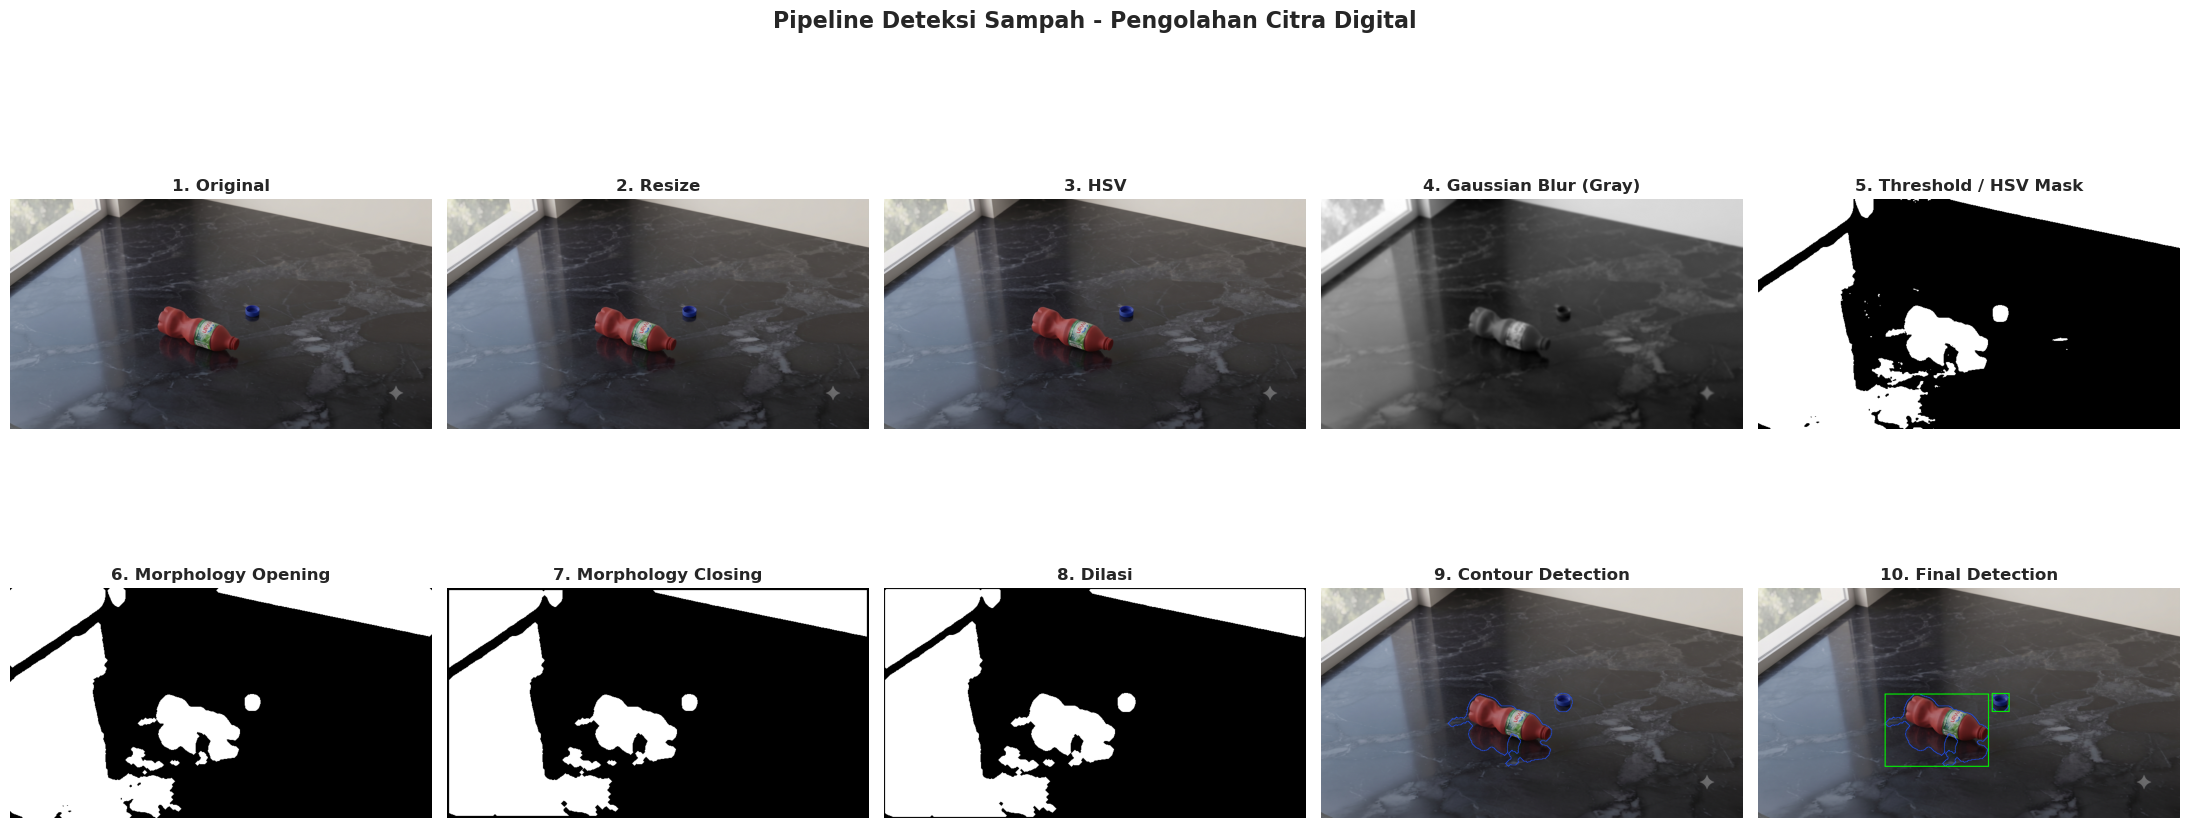

In [82]:
def hsv_to_displayable_rgb(hsv_array):
    # Konversi HSV kembali ke RGB agar bisa ditampilkan
    from matplotlib.colors import hsv_to_rgb
    return hsv_to_rgb(hsv_array)


def show_pipeline(original_img, resized_img, hsv_img, blur_img, mask_img,
                   opened_img, closed_img, dilated_img, contour_img, final_img):
    # Siapkan daftar gambar dan judul
    images = [
        (original_img, "1. Original"),
        (resized_img, "2. Resize"),
        (hsv_to_displayable_rgb(hsv_img), "3. HSV"),
        (blur_img, "4. Gaussian Blur (Gray)"),
        (mask_img, "5. Threshold / HSV Mask"),
        (opened_img, "6. Morphology Opening"),
        (closed_img, "7. Morphology Closing"),
        (dilated_img, "8. Dilasi"),
        (contour_img, "9. Contour Detection"),
        (final_img, "10. Final Detection"),
    ]
    # Buat grid subplot
    fig, axes = plt.subplots(2, 5, figsize=(22, 10))
    axes = axes.ravel()
    for ax, (img, title) in zip(axes, images):
        cmap = "gray" if img.ndim == 2 else None
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.axis("off")
    fig.suptitle("Pipeline Deteksi Sampah - Pengolahan Citra Digital", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Gambar contour saja di atas citra resize untuk visualisasi tahap 9
contour_only = resized.copy()
struct3 = np.ones((3, 3), dtype=bool)
for obj in detected_objects:
    slc = obj["slice"]
    local_mask = labeled_mask[slc] == obj["label_id"]
    eroded = ndimage.binary_erosion(local_mask, structure=struct3)
    boundary = local_mask & ~eroded
    region = contour_only[slc]
    region[boundary] = CONTOUR_COLOR
    contour_only[slc] = region

show_pipeline(
    original, resized, hsv_image, gray_blurred, binary_mask,
    opened_mask, closed_mask, dilated_mask, contour_only, final_result
)

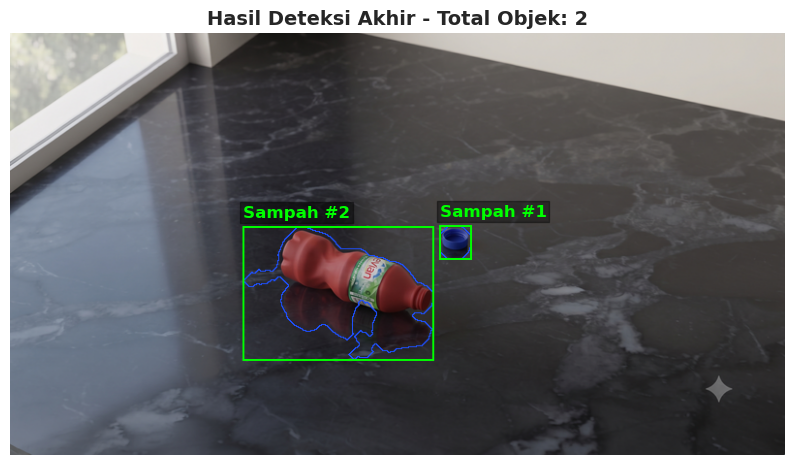

In [83]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(final_result)
for i, obj in enumerate(detected_objects, start=1):
    # Tulis label objek di atas bounding box
    ax.text(obj["x"], max(obj["y"] - 10, 15), f"Sampah #{i}",
            color="lime", fontsize=12, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.4, pad=2))
ax.set_title(f"Hasil Deteksi Akhir - Total Objek: {len(detected_objects)}", fontsize=14, fontweight="bold")
ax.axis("off")
plt.show()

In [84]:
def summary_table(objects):
    # Susun data ke dalam list of dict
    rows = []
    for i, obj in enumerate(objects, start=1):
        rows.append({
            "No": i,
            "Area": int(obj["area"]),
            "Width": obj["width"],
            "Height": obj["height"],
            "X": obj["x"],
            "Y": obj["y"],
        })
    # Buat dataframe pandas
    df = pd.DataFrame(rows)
    return df


hasil_df = summary_table(detected_objects)
hasil_df

,No,Area,Width,Height,X,Y
0,1,1007,34,36,443,199
1,2,14123,198,139,240,200


In [85]:
print("=" * 50)
print("RINGKASAN DETEKSI SAMPAH")
print("=" * 50)
print(f"Total objek terdeteksi : {len(detected_objects)}")
print(f"Total contour mentah   : {len(component_slices)}")
print(f"Contour terbuang       : {len(component_slices) - len(detected_objects)}")
print("=" * 50)
hasil_df

RINGKASAN DETEKSI SAMPAH
Total objek terdeteksi : 2
Total contour mentah   : 6
Contour terbuang       : 4


,No,Area,Width,Height,X,Y
0,1,1007,34,36,443,199
1,2,14123,198,139,240,200
